# **RQ 3**: DO the anglicisms tend to be central?

Two measures are computed in order to investigate this phenomenon:

1. *PageRank*, to compute the semantic centrality of the word;
2. *Participation Coefficient*, to compute the cross-community connectivity. If the node is near 0, it talks only with its community; otherwise, it connects more communities

In [2]:
import igraph as ig
import pandas as pd
import numpy as np
import os
from pathlib import Path
import nltk
from nltk.corpus import words as nltk_words
import matplotlib.pyplot as plt

Configurazione rilevatore Anglismi...


[nltk_data] Downloading package words to
[nltk_data]     C:\Users\leona\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


Inizio analisi RQ3 (Anglismi)...
Processing 1... Fatto.
Processing 2... Fatto.
Processing 3... Fatto.
Processing 4... Fatto.
Processing 5... Fatto.
Processing 6... Fatto.
Processing 7... Fatto.
Processing 8... Fatto.
Processing 9... Fatto.
Processing 10... Fatto.


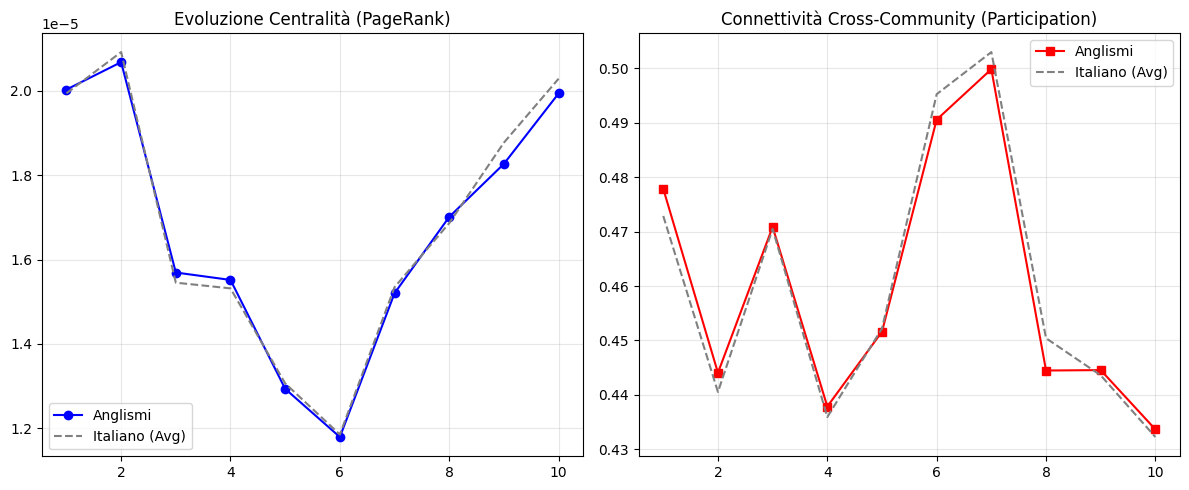


--- ESEMPIO DATI RQ3 ---
   year  num_anglicisms  ratio_centrality  avg_participation_anglo  \
0     1            2807          1.004457                 0.477871   
1     2            2696          0.988587                 0.444043   
2     3            3228          1.015583                 0.470867   
3     4            3373          1.013056                 0.437840   
4     5            3994          0.990114                 0.451599   

                                  top_anglicisms  
0  richmond, virgilia, ladrone, superman, pingue  
1       force, discontinue, british, cade, viver  
2      sidecar, atone, bruce, antigone, anasarca  
3       incline, andre, intima, olivia, cubitale  
4            canape, queen, aloe, platine, david  
   year  num_anglicisms  ratio_centrality  avg_participation_anglo  \
5     6            4310          0.994906                 0.490593   
6     7            3904          0.990708                 0.499875   
7     8            3639          1.00

In [3]:
# --- 1. SETUP RILEVATORE ANGLISMI ---
print("Configurazione rilevatore Anglismi...")

# A. Dizionario Inglese
nltk.download('words')
english_vocab = set(w.lower() for w in nltk_words.words())

# B. Dizionario Italiano (NVdB) che hai già caricato prima
try:
    nvdb = pd.read_csv('nvdb.csv').set_index('lemma')['categoria'].to_dict()
    italian_vocab = set(nvdb.keys())
except:
    print("NVdB non trovato, userò solo euristiche (meno preciso).")
    italian_vocab = set()

# C. Lista Manuale di "Falsi Amici" (Parole uguali in IT/EN da NON contare come anglismi)
# Aggiungi qui parole che vedi erroneamente classificate
false_friends = {
    "area", "data", "media", "camera", "fine", "fame", "mare", "male", 
    "sale", "note", "base", "piano", "zero", "uno", "due", "no", "si", 
    "latina", "arena", "vision", "mission", "radio", "video", "virus", 
    "agenda", "alibi", "atlas", "bonus", "campus", "cinema", "item", "tram", "bar" 
    # Tram e Bar sono prestiti storici ormai italianizzati, decidi tu se includerli o no.
}

def is_anglicism(word):
    """Restituisce True se la parola è probabilmente un anglismo recente"""
    if len(word) < 3: return False
    if word in false_friends: return False
    
    # Se è nel dizionario italiano, NON è un anglismo (escludiamo prestiti storici consolidati)
    if word in italian_vocab: return False
    
    # Se è nel dizionario inglese
    if word in english_vocab:
        return True
        
    return False

# --- 2. FUNZIONE PARTECIPATION COEFFICIENT ---
def calculate_participation(G, clustering):
    """
    Calcola il Participation Coefficient (P) per ogni nodo.
    P misura quanto uniformemente un nodo distribuisce i suoi link tra le comunità.
    """
    # Membership list: a quale comunità appartiene ogni nodo
    membership = clustering.membership
    num_communities = len(clustering)
    
    # Grado totale di ogni nodo
    degrees = np.array(G.degree())
    
    # Preparare struttura per contare link intra-community
    # participation = 1 - sum((kis / ki)^2)
    
    participation_scores = []
    
    for v_idx, v in enumerate(G.vs):
        k_i = degrees[v_idx]
        if k_i == 0:
            participation_scores.append(0.0)
            continue
            
        # Ottieni vicini
        neighbors = G.neighbors(v)
        
        # Conta quanti vicini sono in ciascuna comunità
        community_counts = {}
        for neighbor in neighbors:
            comm_id = membership[neighbor]
            community_counts[comm_id] = community_counts.get(comm_id, 0) + 1
            
        # Calcolo somma dei quadrati delle frazioni
        sum_sq = 0.0
        for count in community_counts.values():
            ratio = count / k_i
            sum_sq += ratio * ratio
            
        p_i = 1 - sum_sq
        participation_scores.append(p_i)
        
    return participation_scores

# --- 3. ANALISI LONGITUDINALE ---
input_dir = Path("networks_annotated") # Usa i file annotati o quelli base
files = sorted([f for f in os.listdir(input_dir) if "snap" in f], 
               key=lambda x: int(x.split("_")[1].replace("snap", "")))

rq3_results = []

print("Inizio analisi RQ3 (Anglismi)...")

for file in files:
    try:
        year = int(file.split("_")[1].replace("snap", ""))
    except: continue
        
    print(f"Processing {year}...", end="")
    
    # Carica Grafo
    path = input_dir / file
    G = ig.Graph.Read_Pickle(str(path))
    
    if G.vcount() == 0: continue

    # 1. Rilevamento Anglismi
    # (Potresti salvarlo come attributo del nodo per non rifarlo)
    node_names = G.vs['token']
    is_anglo_mask = [is_anglicism(w) for w in node_names]
    
    # Converti in array booleano per filtraggio facile
    is_anglo_arr = np.array(is_anglo_mask)
    num_anglo = np.sum(is_anglo_arr)
    
    if num_anglo == 0:
        print(f" Nessun anglismo trovato (strano).")
        continue

    # 2. Calcolo Centralità (PageRank)
    pagerank = np.array(G.pagerank(weights='weight'))
    # Normalizza PageRank per confrontare anni diversi (somma=1, ma meglio *N)
    # pagerank_norm = pagerank * G.vcount() 
    
    # 3. Calcolo Comunità e Participation Coefficient
    # Usiamo Leiden (più veloce/stabile di Louvain)
    clusters = G.community_leiden(objective_function="modularity", weights='weight')
    participation = np.array(calculate_participation(G, clusters))
    
    # 4. Aggregazione Dati (Anglismi vs Italiani)
    
    # Gruppo Anglismi
    pr_anglo = np.mean(pagerank[is_anglo_arr])
    part_anglo = np.mean(participation[is_anglo_arr])
    
    # Gruppo Italiani (Non-Anglismi)
    pr_it = np.mean(pagerank[~is_anglo_arr])
    part_it = np.mean(participation[~is_anglo_arr])
    
    # Top 5 Anglismi per importanza (Controllo qualità)
    # Prendiamo gli indici degli anglismi, ordiniamo per pagerank
    anglo_indices = np.where(is_anglo_arr)[0]
    top_anglo_idx = anglo_indices[np.argsort(pagerank[anglo_indices])[-5:]]
    top_anglo_words = [node_names[i] for i in top_anglo_idx]
    
    rq3_results.append({
        "year": year,
        "num_anglicisms": num_anglo,
        "perc_vocab_anglo": num_anglo / G.vcount(),
        
        # Centralità
        "avg_pagerank_anglo": pr_anglo,
        "avg_pagerank_italian": pr_it,
        "ratio_centrality": pr_anglo / pr_it, # Se > 1, gli anglismi sono più centrali della media
        
        # Connettività Cross-Community
        "avg_participation_anglo": part_anglo,
        "avg_participation_italian": part_it,
        
        "top_anglicisms": ", ".join(top_anglo_words)
    })
    
    print(" Fatto.")

df_rq3 = pd.DataFrame(rq3_results)


# --- VISUALIZZAZIONE ---

plt.figure(figsize=(12, 5))

# Plot 1: Trend Centralità
plt.subplot(1, 2, 1)
plt.plot(df_rq3['year'], df_rq3['avg_pagerank_anglo'], label='Anglismi', color='blue', marker='o')
plt.plot(df_rq3['year'], df_rq3['avg_pagerank_italian'], label='Italiano (Avg)', color='grey', linestyle='--')
plt.title("Evoluzione Centralità (PageRank)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Trend Participation (Cross-Community)
plt.subplot(1, 2, 2)
plt.plot(df_rq3['year'], df_rq3['avg_participation_anglo'], label='Anglismi', color='red', marker='s')
plt.plot(df_rq3['year'], df_rq3['avg_participation_italian'], label='Italiano (Avg)', color='grey', linestyle='--')
plt.title("Connettività Cross-Community (Participation)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- ESEMPIO DATI RQ3 ---")
print(df_rq3[['year', 'num_anglicisms', 'ratio_centrality', 'avg_participation_anglo', 'top_anglicisms']].head())
print(df_rq3[['year', 'num_anglicisms', 'ratio_centrality', 'avg_participation_anglo', 'top_anglicisms']].tail())

In [ ]:
# --- FUNZIONI DI SUPPORTO ---

def calculate_within_module_z_score(G, clustering, weights='weight'):
    """
    Calcola lo z-score del grado interno alla comunità.
    z_i = (k_i - k_avg_s) / sigma_k_s
    Dove k_i è il grado interno del nodo i nella sua comunità s,
    k_avg_s e sigma_k_s sono media e dev. std dei gradi interni nella comunità s.
    """
    membership = np.array(clustering.membership)
    num_comm = len(clustering)
    
    # 1. Calcola il grado interno per ogni nodo (Weighted)
    # Purtroppo igraph non ha una funzione nativa per "grado verso un sottoinsieme", 
    # dobbiamo iterare sugli archi o usare sottografi. 
    # Metodo veloce con matrice di adiacenza sparsa se possibile, o iterazione ottimizzata.
    
    # Per velocità su 50k nodi, usiamo un approccio basato sugli archi
    internal_degrees = np.zeros(G.vcount())
    
    # Iteriamo sugli archi (più veloce che sui nodi per calcolare k_internal)
    for e in G.es:
        u, v = e.source, e.target
        w = e[weights] if weights else 1
        if membership[u] == membership[v]:
            internal_degrees[u] += w
            internal_degrees[v] += w
            
    # 2. Calcola media e std per ogni comunità
    z_scores = np.zeros(G.vcount())
    
    for c in range(num_comm):
        # Indici dei nodi nella comunità c
        nodes_in_c = np.where(membership == c)[0]
        
        if len(nodes_in_c) < 2:
            z_scores[nodes_in_c] = 0
            continue
            
        k_vals = internal_degrees[nodes_in_c]
        mean_k = np.mean(k_vals)
        std_k = np.std(k_vals)
        
        if std_k == 0:
            z_scores[nodes_in_c] = 0
        else:
            z_scores[nodes_in_c] = (k_vals - mean_k) / std_k
            
    return z_scores

# (Reinserisco la tua funzione Participation se non ce l'hai già caricata)
def calculate_participation(G, clustering):
    membership = clustering.membership
    degrees = np.array(G.degree())
    participation_scores = []
    for v_idx, v in enumerate(G.vs):
        k_i = degrees[v_idx]
        if k_i == 0:
            participation_scores.append(0.0)
            continue
        neighbors = G.neighbors(v)
        community_counts = {}
        for neighbor in neighbors:
            comm_id = membership[neighbor]
            community_counts[comm_id] = community_counts.get(comm_id, 0) + 1
        sum_sq = sum((count / k_i)**2 for count in community_counts.values())
        participation_scores.append(1 - sum_sq)
    return np.array(participation_scores)

# --- ANALISI ---

input_dir = Path("networks_annotated") 
files = sorted([f for f in os.listdir(input_dir) if "snap" in f], 
               key=lambda x: int(x.split("_")[1].replace("snap", "")))

rq3_advanced = []

print("Inizio analisi avanzata RQ3 (Cartografia z-P)...")

for file in files:
    try:
        year = int(file.split("_")[1].replace("snap", ""))
    except: continue
        
    print(f"Analisi {year}...", end="")
    
    path = input_dir / file
    G = ig.Graph.Read_Pickle(str(path))
    
    # 1. Identificazione Gruppi
    # Recuperiamo gli attributi se li hai salvati, o ricalcoliamo al volo
    node_names = G.vs['token']
    
    # MASK ANGLISMI (Usa la tua funzione is_anglicism definita prima)
    is_anglo = np.array([is_anglicism(w) for w in node_names])
    
    # MASK CONTROLLO: Parole Italiane COMPLESSE (De Mauro 'Altro' o IDF alto)
    # Escludiamo le parole comuni (FO/AU) per un confronto equo
    if 'demauro_level' in G.vs.attributes():
        dm_levels = np.array(G.vs['demauro_level'])
        # 0=FO, 1=AU, 2=AD, 3=Altro. 
        # Confrontiamo con parole "semanticamente dense" (livello 3)
        mask_control = (dm_levels == 3) & (~is_anglo)
    else:
        # Fallback se non hai attributi: usa tutte le non-anglo
        mask_control = ~is_anglo

    # 2. Calcolo Comunità (Leiden)
    clusters = G.community_leiden(objective_function="modularity", weights='weight')
    
    # 3. Calcolo Metriche Cartografiche (z-score e P)
    z_scores = calculate_within_module_z_score(G, clusters, weights='weight')
    participation = calculate_participation(G, clusters)
    
    # 4. Betweenness Centrality (Solo se il grafo non è immenso, < 10k nodi, altrimenti salta)
    # Su 50k nodi è lenta. Usiamo una stima basata sul Weighted Degree come proxy, 
    # oppure Betweenness calcolata solo sui nodi anglo e controllo (più veloce).
    # Per ora usiamo z e P che sono più significativi per la RQ3.

    # 5. Aggregazione
    
    # Anglismi
    anglo_z = np.mean(z_scores[is_anglo])
    anglo_p = np.mean(participation[is_anglo])
    
    # Controllo (Italiano Complesso)
    ctrl_z = np.mean(z_scores[mask_control])
    ctrl_p = np.mean(participation[mask_control])
    
    # Classificazione Ruoli (Guimerà-Amaral)
    # R3: Non-hub connector (z < 2.5, P > 0.62) -> Il vero "Ponte"
    # R6: Connector Hub (z > 2.5, P > 0.62) -> Leader globale
    
    # Contiamo quanti anglismi sono "Connettori" (P > 0.62 è la soglia teorica, ma 0.5 è pratica)
    threshold_P = 0.5 
    num_anglo_connectors = np.sum((participation[is_anglo] > threshold_P))
    perc_anglo_connectors = num_anglo_connectors / np.sum(is_anglo) if np.sum(is_anglo) > 0 else 0
    
    num_ctrl_connectors = np.sum((participation[mask_control] > threshold_P))
    perc_ctrl_connectors = num_ctrl_connectors / np.sum(mask_control) if np.sum(mask_control) > 0 else 0

    rq3_advanced.append({
        "year": year,
        "z_anglo": anglo_z,
        "z_control": ctrl_z,
        "p_anglo": anglo_p,
        "p_control": ctrl_p,
        "gap_participation": anglo_p - ctrl_p, # Se > 0, anglismi più cosmopoliti
        "perc_anglo_connectors": perc_anglo_connectors,
        "perc_control_connectors": perc_ctrl_connectors
    })
    
    print(" Fatto.")
df_adv = pd.DataFrame(rq3_advanced)
print(df_adv.head())

Inizio analisi avanzata RQ3 (Cartografia z-P)...
Analisi 1... Fatto.
Analisi 2... Fatto.
Analisi 3... Fatto.
Analisi 4... Fatto.
Analisi 5... Fatto.
Analisi 6... Fatto.
Analisi 7... Fatto.
Analisi 8... Fatto.
Analisi 9... Fatto.
Analisi 10... Fatto.
   year   z_anglo  z_control   p_anglo  p_control  gap_participation  \
0     1 -0.003920  -0.002091  0.473247   0.467405           0.005842   
1     2 -0.021432   0.000039  0.442995   0.439748           0.003247   
2     3 -0.006859   0.000620  0.469074   0.466902           0.002172   
3     4  0.018370  -0.000624  0.438237   0.436683           0.001554   
4     5  0.000405  -0.002757  0.449402   0.449641          -0.000239   

   perc_anglo_connectors  perc_control_connectors  
0               0.530816                 0.519869  
1               0.473294                 0.470660  
2               0.505266                 0.507656  
3               0.447376                 0.449669  
4               0.491738                 0.489337  
